In [39]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")


In [41]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

In [43]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [45]:
sns.boxplot(df[['Age',	'Annual Income (k$)','Spending Score (1-100)']])
plt.close()

In [47]:
le = LabelEncoder()

In [48]:
df['Gender_Id']=le.fit_transform(df['Gender']) #To inverse it after deleting use inverse_transform()
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Id
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,1


In [51]:
#df= df.drop(columns='Gender')

In [53]:
#df['Gender']= le.inverse_transform(df['Gender_Id'])

In [100]:
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,1,19,15,39,0.0,1.0
1,2,21,15,81,0.0,1.0
2,3,20,16,6,1.0,0.0
3,4,23,16,77,1.0,0.0
4,5,31,17,40,1.0,0.0
...,...,...,...,...,...,...
195,196,35,120,79,1.0,0.0
196,197,45,126,28,1.0,0.0
197,198,32,126,74,0.0,1.0
198,199,32,137,18,0.0,1.0


In [102]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [104]:
df.columns 

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [106]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

In [108]:
gender_encoder= encoder.fit_transform(df[['Gender']])
gender_encoder

<200x2 sparse matrix of type '<class 'numpy.float64'>'
	with 200 stored elements in Compressed Sparse Row format>

In [110]:
encoder = OneHotEncoder(sparse_output=False)

In [112]:
gender_encoder = OneHotEncoder(sparse_output=False)

gender = gender_encoder.fit_transform(df[['Gender']])

gender_df = pd.DataFrame(
    gender,
    columns=gender_encoder.get_feature_names_out(['Gender'])
)

gender_df

,Gender_Female,Gender_Male
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
195,1.0,0.0
196,1.0,0.0
197,0.0,1.0
198,0.0,1.0


In [114]:
#df = df.drop(columns=['Gender_Female', 'Gender_Male'])

#df = df.join(gender_df)

In [116]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

gender_encoded = encoder.fit_transform(df[['Gender']])

gender_df = pd.DataFrame(
    gender_encoded,
    columns=encoder.get_feature_names_out(['Gender']),
    index=df.index
)

df = df.join(gender_df)
df = df.drop('Gender', axis=1)

In [118]:
df.columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Female', 'Gender_Male'],
      dtype='object')

In [132]:
X=df[['CustomerID', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)','Gender_Female', 'Gender_Male']]

In [134]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female', 'Gender_Male']


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [149]:
k_range = range(1, 21)
error_rate=[]

In [155]:
for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(X_scaled)
    error_rate.append(kmeans.inertia_)
    
    

Text(0.5, 1.0, 'Elbow diagram')

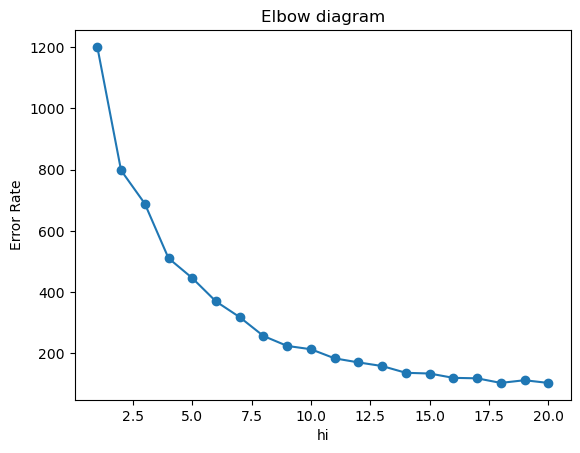

In [161]:
plt.plot(k_range, error_rate, marker='o')
plt.xlabel('hi')
plt.ylabel('Error Rate')
plt.title('Elbow diagram')

In [165]:
k = 5 
model = KMeans(n_clusters=5)
cluster= model.fit_predict(X_scaled)


In [177]:
df['cluster']=cluster
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster
0,1,19,15,39,0.0,1.0,2
1,2,21,15,81,0.0,1.0,2
2,3,20,16,6,1.0,0.0,3
3,4,23,16,77,1.0,0.0,3
4,5,31,17,40,1.0,0.0,3
...,...,...,...,...,...,...,...
195,196,35,120,79,1.0,0.0,1
196,197,45,126,28,1.0,0.0,1
197,198,32,126,74,0.0,1.0,2
198,199,32,137,18,0.0,1.0,4


In [197]:
sc = silhouette_score(X_scaled, cluster)
print(f'Cluster Silhouette Score:{sc}')

Cluster Silhouette Score:0.3338943134189391


In [200]:
'''
 Silhouette Score (-1 to 1+)
 ----------------------------
  -1 : All clusters forms in one cloud formation.(Wrong Clusters)

  Near 0 and below 1 :Some clusters overlap eachother.(Considerable)


  1+:All clusters are far distance from other cluster.(Perfect Cluster Formation)
  '''

'\n Silhouette Score (-1 to 1+)\n ----------------------------\n  -1 : All clusters forms in one cloud formation.(Wrong Clusters)\n\n  Near 0 and below 1 :Some clusters overlap eachother.(Considerable)\n\n\n  1+:All clusters are far distance from other cluster.(Perfect Cluster Formation)\n  '

In [202]:
df['cluster']=cluster
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster
0,1,19,15,39,0.0,1.0,2
1,2,21,15,81,0.0,1.0,2
2,3,20,16,6,1.0,0.0,3
3,4,23,16,77,1.0,0.0,3
4,5,31,17,40,1.0,0.0,3
...,...,...,...,...,...,...,...
195,196,35,120,79,1.0,0.0,1
196,197,45,126,28,1.0,0.0,1
197,198,32,126,74,0.0,1.0,2
198,199,32,137,18,0.0,1.0,4


<Axes: xlabel='Annual Income (k$)', ylabel='Age'>

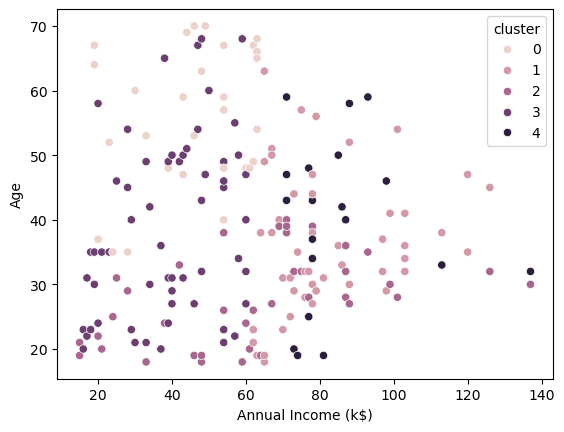

In [209]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Age',
    hue='cluster',
   
)

In [205]:
print(df.columns)

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Female', 'Gender_Male', 'cluster'],
      dtype='object')


### pair plot

In [220]:
pair_plot = df

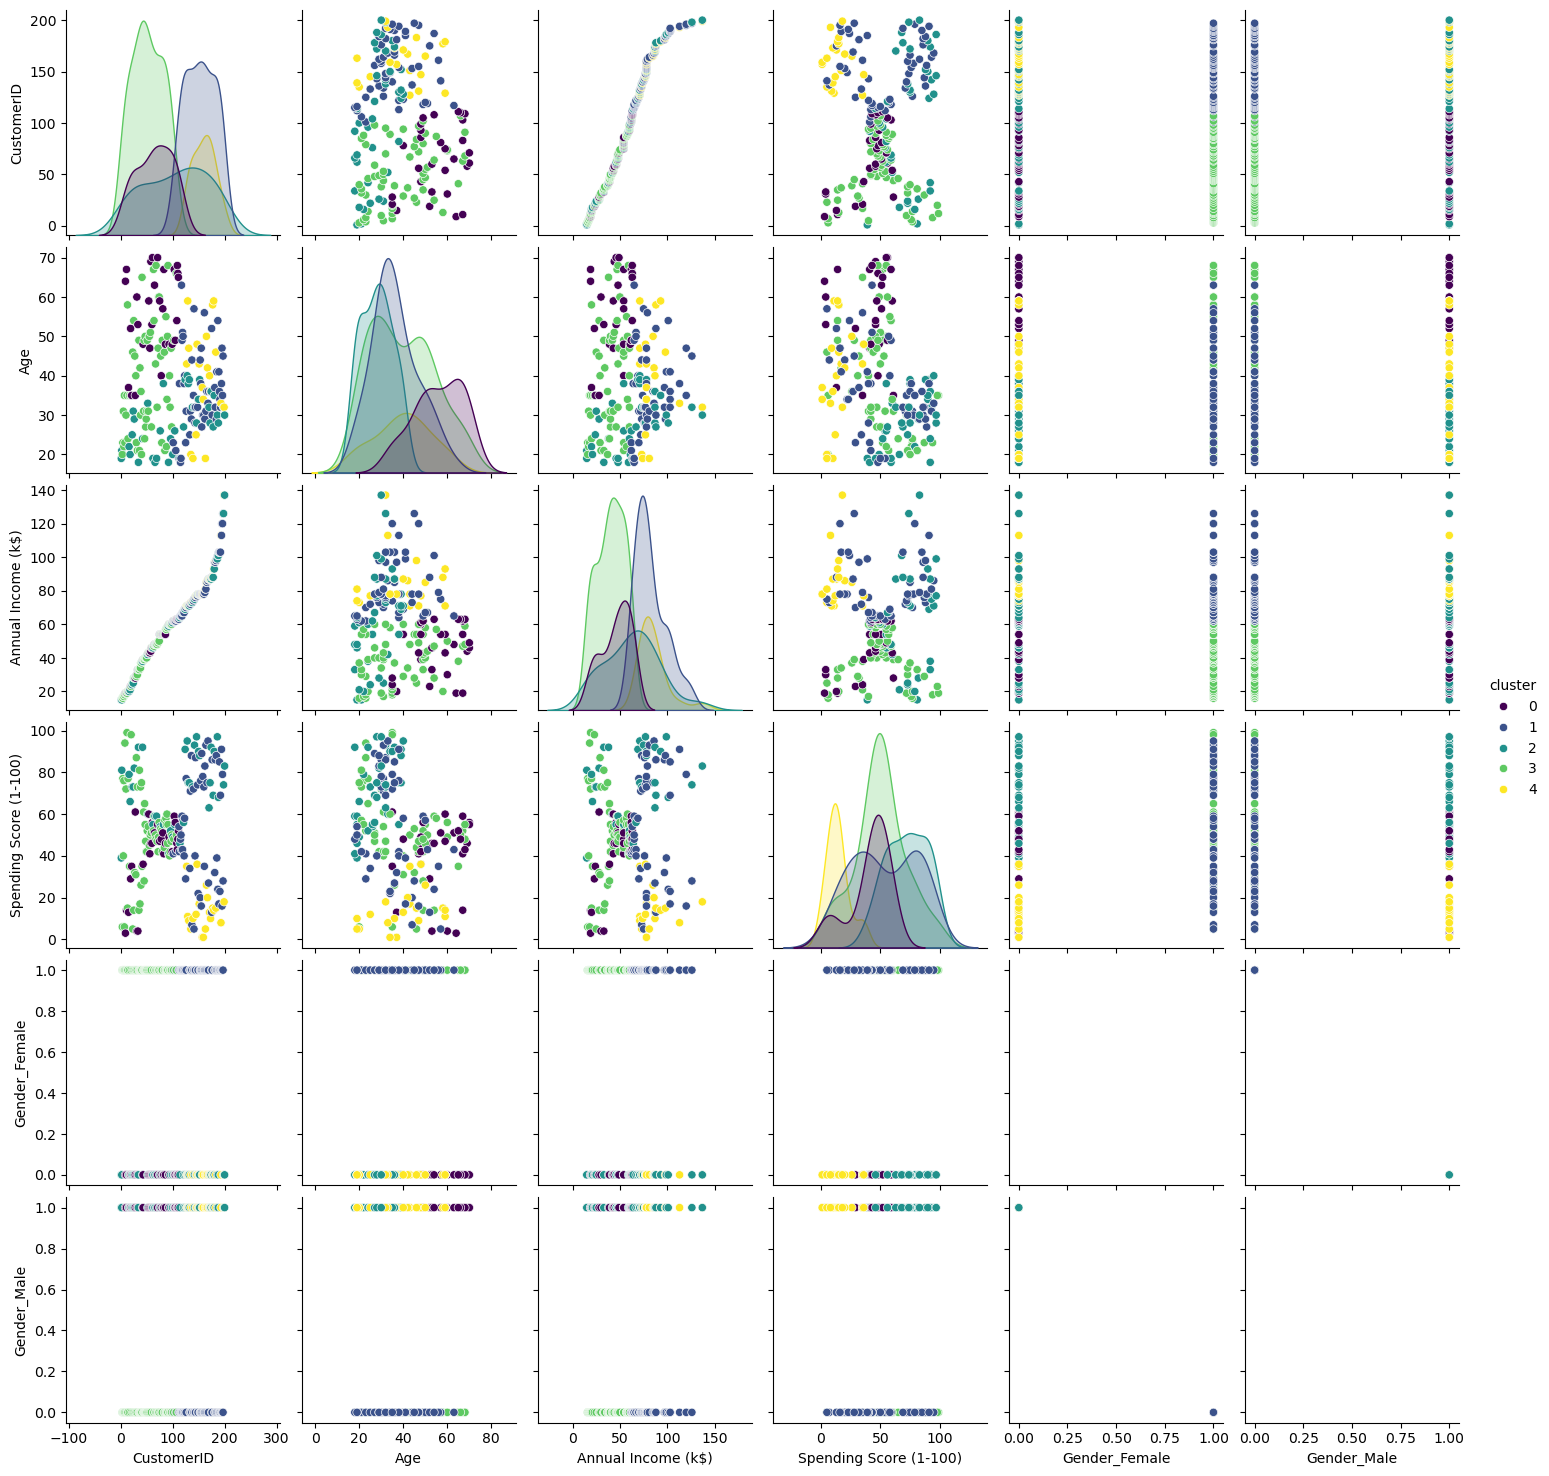

In [226]:
sns.pairplot(
    pair_plot,
    hue='cluster',
    palette='viridis'
)